# Stochastic Processes and Time Series Foundations

A stochastic process specifies possible histories. A realized time series records only part of one of those histories. Before introducing models, I distinguish their population properties from what can be learned from finite observations.

Temporal ordering matters. The iid assumption used in earlier simulations no longer describes every process considered here. Marginal distributions alone cannot determine dependence through time.

In [1]:
from pathlib import Path
import sys
repository = Path.cwd()
if not (repository / "src" / "finstats").is_dir():
    repository = repository.parent
if not (repository / "src" / "finstats").is_dir():
    raise RuntimeError("Run from the repository root or notebooks directory")
sys.path.insert(0, str(repository / "src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from IPython.display import display
from finstats.descriptive import (
    sample_mean, sample_variance, sample_standard_deviation,
    sample_skewness, sample_kurtosis,
)
plt.rcParams.update({
    "figure.figsize": (7,4), "figure.dpi": 110,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": False, "font.size": 11, "axes.titlesize": 12,
    "legend.frameon": False, "lines.linewidth": 1.8,
})

from finstats.timeseries.diagnostics import sample_autocovariance, sample_autocorrelation
from finstats.timeseries.nonstationary import simulate_random_walk

## 1. Stochastic Processes

A discrete-time stochastic process is a collection of random variables
$$\{Y_t\}_{t\in\mathbb Z}=\{\ldots,Y_{-1},Y_0,Y_1,\ldots\}.$$
At a fixed time, $Y_t$ is a random variable. A trajectory $\{y_t\}$ is a possible history. For every finite set of time points, the joint distribution
$$F_{Y_{t_1},\ldots,Y_{t_k}}(y_1,\ldots,y_k)$$
is defined. These finite-dimensional distributions include temporal dependence, which individual marginal distributions do not specify.

When second moments exist, the population functions are
$$\mu(t)=E[Y_t],\qquad \gamma(t,s)=\operatorname{Cov}(Y_t,Y_s),$$
$$\sigma^2(t)=\operatorname{Var}(Y_t)=\gamma(t,t),\qquad
\rho(t,s)=\frac{\gamma(t,s)}{\sqrt{\gamma(t,t)\gamma(s,s)}}.$$
Correlation requires positive variances. The functions may depend on calendar time as well as separation between observations.

## 2. Realized Time Series

A time series $y_1,\ldots,y_n$ is one partial realization of the underlying process. The DGP can generate many other histories with the same population properties.

For illustration, I generate ten independent histories of length 150 from an iid $N(0,1)$ process, with seed 501. One highlighted history represents the observed series. The other paths show possibilities that would not be observed alongside it in an actual single-series dataset.

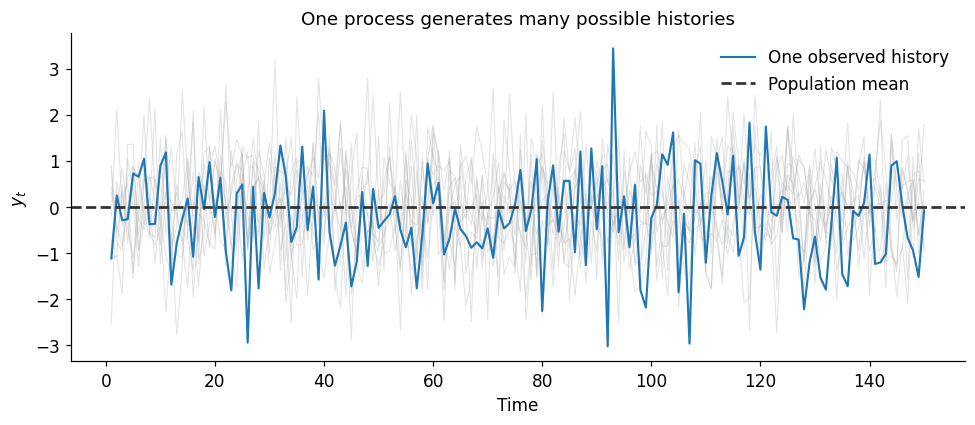

In [2]:
histories = np.random.default_rng(501).normal(size=(10, 150))
observed = histories[0]
times = np.arange(1, 151)
fig, ax = plt.subplots(figsize=(9, 4))
for path in histories[1:]:
    ax.plot(times, path, color="0.65", alpha=.3, linewidth=.7)
ax.plot(times, observed, color="C0", linewidth=1.4, label="One observed history")
ax.axhline(0, color="0.2", linestyle="--", label="Population mean")
ax.set(xlabel="Time", ylabel="$y_t$", title="One process generates many possible histories")
ax.legend()
fig.tight_layout()
plt.show()

For the observed history, the sample counterparts are
$$\bar y=\frac1n\sum_{t=1}^n y_t,\qquad
\hat\gamma_j=\frac1{n-j}\sum_{t=j+1}^n(y_t-\bar y)(y_{t-j}-\bar y),\qquad
\hat\rho_j=\frac{\hat\gamma_j}{\hat\gamma_0}.$$
The lag-zero value uses denominator $n$. The usual adjusted sample variance is $s^2=n\hat\gamma_0/(n-1)$, so it has a different denominator. This adjustment does not generally make variance estimation unbiased under temporal dependence.

Population moments describe the DGP, whereas these summaries describe its finite realized history. Ergodicity supplies the additional justification for using a sufficiently long history to learn population moments. Stationarity alone does not guarantee that learning is possible.

In [3]:
display(pd.DataFrame({
    "Population": [0., 1., 0.],
    "Observed history": [sample_mean(observed), sample_autocovariance(observed, 0), sample_autocorrelation(observed, 1)],
}, index=["Mean", "Variance (denominator n)", "Lag-one correlation"]))

,Population,Observed history
Mean,0.0,-0.244925
Variance (denominator n),1.0,1.095659
Lag-one correlation,0.0,-0.143496


## 3. Non-stationary Stochastic Processes

Non-stationarity means that distributional properties are not invariant to time shifts. A changing mean or variance already rules out second-order stationarity.

### Deterministic linear trend

The course model is
$$Y_t=\beta_0+\beta_1t+\varepsilon_t,\qquad\varepsilon_t\sim WN(0,\sigma^2).$$
Its mean is $\beta_0+\beta_1t$, while variance is $\sigma^2$. With a stationary error process, removing the deterministic trend leaves a stationary process. Shocks are deviations around a fixed trend rather than permanent additions to its level.

### Random walk and drift

Starting at a fixed $Y_0=y_0$,
$$Y_t=Y_{t-1}+\varepsilon_t=y_0+\sum_{i=1}^t\varepsilon_i.$$
Uncorrelated mean-zero shocks give
$$E[Y_t]=y_0,\quad\operatorname{Var}(Y_t)=t\sigma^2,\quad
\operatorname{Cov}(Y_t,Y_s)=\sigma^2\min(t,s).$$
The covariance counts the shocks shared by the two sums. Variance grows with time, so a constant mean does not make the random walk stationary.

With drift, $Y_t=Y_{t-1}+\delta+\varepsilon_t$ has mean $y_0+\delta t$ and the same growing variance. Removing its expected linear trend still leaves a random walk. This distinguishes a stochastic trend from a trend-stationary process.

For illustration, I retain the course parameters $n=300$, $y_0=10$, $\beta_0=10$, $\beta_1=.1$ and innovation SD $.5$, using seed 506 and five histories per case. The drift illustration uses $\delta=.1$. Common innovations make the different shock accumulation mechanisms comparable.

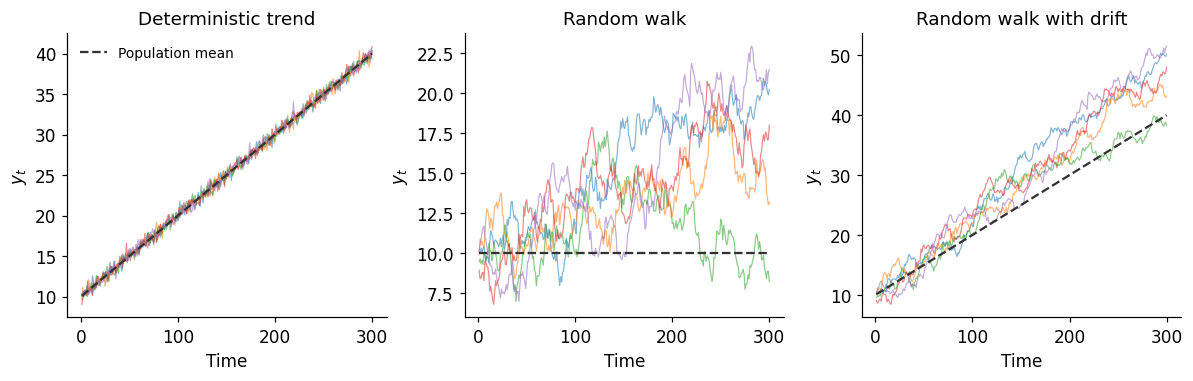

In [4]:
rng_trends = np.random.default_rng(506)
t = np.arange(1, 301)
trend = 10+.1*t
walk_histories = np.array([simulate_random_walk(300, .5, initial=10, rng=rng_trends) for _ in range(5)])
trend_shocks = np.diff(walk_histories, axis=1)
trend_paths = trend+trend_shocks
walk_paths = walk_histories[:, 1:]
fig, axes = plt.subplots(1, 3, figsize=(11, 3.6))
for ax, paths, expectation, title in (
    (axes[0], trend_paths, trend, "Deterministic trend"),
    (axes[1], walk_paths, np.full(300, 10.), "Random walk"),
    (axes[2], walk_paths+.1*t, 10+.1*t, "Random walk with drift"),
):
    for path in paths:
        ax.plot(t, path, alpha=.55, linewidth=.8)
    ax.plot(t, expectation, "--", color="0.2", linewidth=1.5, label="Population mean")
    ax.set(xlabel="Time", ylabel="$y_t$", title=title)
axes[0].legend(fontsize=9)
fig.tight_layout()
plt.show()

## 4. Stationary Stochastic Processes

Stationarity makes observations at different dates comparable at the population level. It does not eliminate dependence or make a finite series representative automatically.

### Strict and second-order stationarity

Strict stationarity requires, for every finite set of dates and time shift $h$,
$$F_{Y_{t_1},\ldots,Y_{t_k}}(y)=F_{Y_{t_1+h},\ldots,Y_{t_k+h}}(y).$$
Second-order, weak or covariance stationarity requires finite second moments and
$$E[Y_t]=\mu,\qquad\operatorname{Cov}(Y_t,Y_{t-j})=\gamma_j.$$
Thus variance is constant at $\gamma_0$ and $\rho_j=\gamma_j/\gamma_0$. Strict stationarity with finite second moments implies weak stationarity. The reverse does not generally hold.

### Ergodicity

The course emphasizes moment ergodicity: under the relevant conditions,
$$\bar Y\xrightarrow{P}\mu,\qquad\hat\gamma_j\xrightarrow{P}\gamma_j,\qquad\hat\rho_j\xrightarrow{P}\rho_j.$$
Stationarity concerns stability across time. Ergodicity concerns what a long single history reveals about the population. These are separate properties. Convergence of the displayed moments is the aspect needed here, rather than a general characterization of every form of ergodicity.

### White noise, IID noise and Gaussian white noise

White noise $Y_t\sim WN(0,\sigma^2)$ requires
$$E[Y_t]=0,\quad\operatorname{Var}(Y_t)=\sigma^2,\quad\operatorname{Cov}(Y_t,Y_{t-j})=0\quad(j\ne0).$$
It imposes zero serial correlation, not independence. IID white noise adds independent, identically distributed observations with those moments. Gaussian white noise adds the common Gaussian law,
$$Y_t\overset{iid}{\sim}N(0,\sigma^2).$$
A Gaussian marginal distribution alone does not establish joint Gaussianity or independence.

### Gaussian stochastic processes

A Gaussian process has a multivariate Gaussian distribution for every finite vector $(Y_{t_1},\ldots,Y_{t_k})$. Its marginal, conditional and linear-combination distributions are Gaussian. For such a process, zero cross-time covariance implies independence. A Gaussian process is not necessarily stationary, but weak stationarity implies strict stationarity for a Gaussian process because its mean and covariance determine every finite-dimensional distribution.

Given a stationary process, or an appropriate stationary transformation, the next question is how to construct explicit models of dependence. Notebook 08 develops conditional-mean models and their conditional-variance counterparts.